# Training an Unconditional Latent Diffusion Model

This notebook trains a Latent Diffusion Model (LDM) on your own set of images.

**How it works:**
1. **VAE (Autoencoder):** We use a pre-trained VAE to compress your 512x512 images into small 64x64 "latent" representations. This makes training efficient.
2. **UNet (Denoiser):** We train a UNet from scratch. Its job is to look at a "noisy" latent and predict the noise that was added.
3. **Sampling:** To generate images, we start with pure noise and repeatedly ask the UNet to remove it, eventually decoding the result back to a 512x512 image.

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.onnx
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image, make_grid
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from diffusers import UNet2DModel, AutoencoderKL, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup

# Use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
IMAGE_SIZE = 512
BATCH_SIZE = 8  # Adjust based on GPU memory
NUM_TIMESTEPS = 1000
NUM_EPOCHS = 100
LR = 1e-4
GRAD_ACCUMULATION_STEPS = 2
SAVE_IMAGE_STEPS = 500  # Save sample images every 500 steps
SAVE_MODEL_EVERY = 10 # Save model weights every 10 epochs
SNAPSHOT_PATH = "output/snapshots"
GENERATED_PATH = "output/images"

os.makedirs(SNAPSHOT_PATH, exist_ok=True)
os.makedirs(GENERATED_PATH, exist_ok=True)

In [3]:
# 1. Dataset Preparation
class ImageDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir)]
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img)

In [4]:
dataset = ImageDataset("datasets/yes-to-the-dress")
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

In [5]:
def show_image(img_tensor):
    img_tensor = img_tensor * 0.5 + 0.5
    if img_tensor.is_cuda:
        img_tensor = img_tensor.cpu()
    img_np = img_tensor.numpy()
    img_np = img_np.transpose((1, 2, 0))  # CHW -> HWC

    plt.imshow(img_np)
    plt.axis("off")
    plt.show()

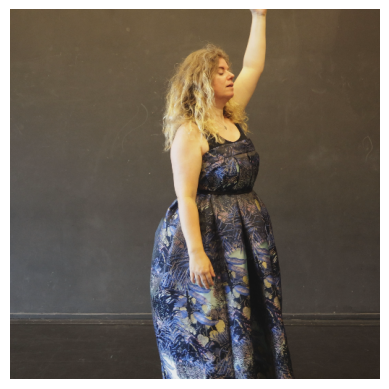

In [6]:
show_image(dataset[1])

In [7]:
# 1. Load Pre-trained VAE (The "Compressor")
# We use standard Stable Diffusion VAE weights to compress 512px -> 64px latents
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
vae.requires_grad_(False) # Freeze VAE
print()

In [8]:
# 2. Create the UNet (The "Denoiser")
# This is an unconditional UNet (no cross-attention for text)
model = UNet2DModel(
    sample_size=64,           # Input size is 64x64 (latent size)
    in_channels=4,            # Latents have 4 channels
    out_channels=4,           # Output predicts noise (4 channels)
    layers_per_block=2,       # Depth of the network
    block_out_channels=(128, 128, 256, 256, 512, 512),
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D", 
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", 
        "UpBlock2D", "UpBlock2D", "UpBlock2D"
    ),
).to(device)

In [9]:
# 3. Noise Scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
print("Models initialized. VAE frozen, UNet ready to train.")

Models initialized. VAE frozen, UNet ready to train.


In [10]:
def sample_images(model, noise_scheduler, vae, n_samples=4):
    model.eval()
    with torch.no_grad():
        # 1. Start with pure random noise in Latent Space (64x64)
        latents = torch.randn((n_samples, 4, 64, 64)).to(device)
        
        # 2. Denoising Loop
        # We go backwards from timestep 1000 -> 0
        for t in tqdm(noise_scheduler.timesteps, desc="Sampling"):
            # Predict noise
            noise_pred = model(latents, t).sample
            
            # Subtract noise (update latents)
            latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

        # 3. Decode Latents back to Image Space (512x512)
        # The scaling factor 0.18215 is specific to the SD VAE
        latents = 1 / 0.18215 * latents
        images = vae.decode(latents).sample

        # 4. Post-process
        images = (images / 2 + 0.5).clamp(0, 1) # Back to [0, 1]
        images = images.cpu()
        
    model.train()
    return images

Epoch 1/100:   0%|          | 0/2900 [00:00<?, ?it/s]


Generating samples at step 500...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

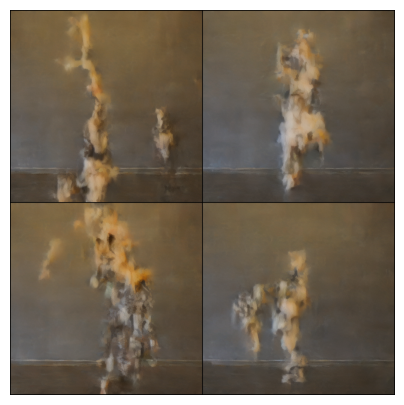

Saved to output/images/out_1_500.png


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 5/100:   0%|          | 0/2900 [00:00<?, ?it/s]


Generating samples at step 6000...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

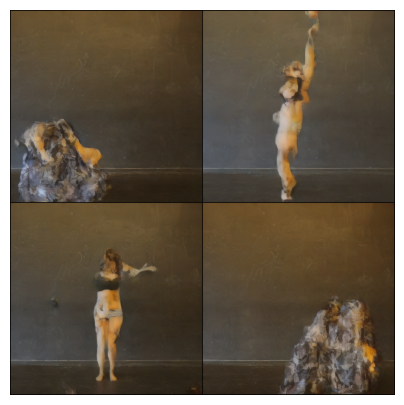

Saved to output/images/out_5_6000.png

Generating samples at step 6500...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

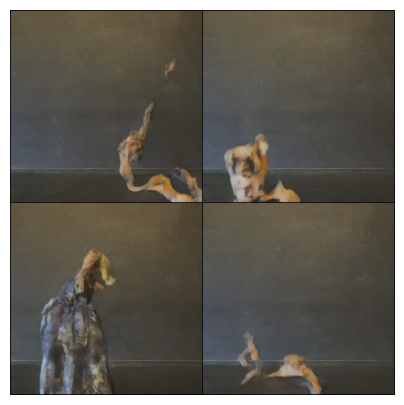

Saved to output/images/out_5_6500.png

Generating samples at step 7000...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

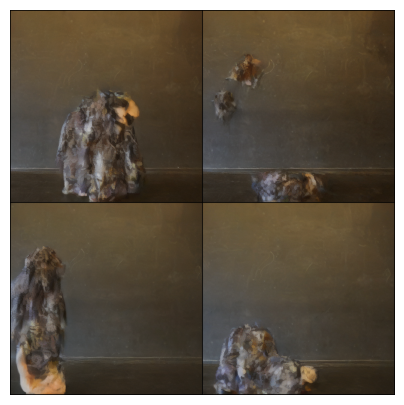

Saved to output/images/out_5_7000.png


Epoch 6/100:   0%|          | 0/2900 [00:00<?, ?it/s]


Generating samples at step 7500...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

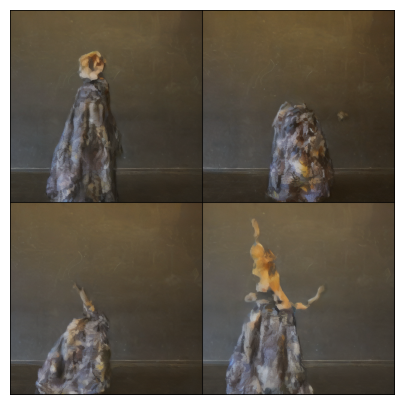

Saved to output/images/out_6_7500.png


In [ ]:
global_step = 0

for epoch in range(NUM_EPOCHS):
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for step, clean_images in enumerate(progress_bar):
        clean_images = clean_images.to(device)
        bs = clean_images.shape[0]

        # 1. Encode
        with torch.no_grad():
            latents = vae.encode(clean_images).latent_dist.sample()
            latents = latents * 0.18215

        # 2. Add Noise
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, NUM_TIMESTEPS, (bs,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 3. Train
        noise_pred = model(noisy_latents, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)
        
        loss.backward()
        
        # Gradient Accumulation Logic
        if (step + 1) % GRAD_ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1

            # --- INTERMEDIATE IMAGE GENERATION ---
            if global_step % SAVE_IMAGE_STEPS == 0:
                print(f"\nGenerating samples at step {global_step}...")
                generated_imgs = sample_images(model, noise_scheduler, vae)
                grid = make_grid(generated_imgs, nrow=2)
                
                # Save as out_{epoch}_{step}.png
                save_filename = f"{GENERATED_PATH}/out_{epoch+1}_{global_step}.png"
                save_image(grid, save_filename)
                
                # Show in notebook
                plt.figure(figsize=(5,5))
                plt.imshow(grid.permute(1, 2, 0))
                plt.axis('off')
                plt.show()
                print(f"Saved to {save_filename}")

        progress_bar.set_postfix(loss=loss.item(), step=global_step)

    # --- Save Model at Interval ---
    if (epoch + 1) % SAVE_MODEL_EVERY == 0:
        save_path = f"{SNAPSHOT_PATH}/model_epoch_{epoch+1}"
        model.save_pretrained(save_path)
        print(f"Model saved to {save_path}")

In [ ]:
# Export the trained UNet to ONNX

print("Exporting UNet to ONNX...")
model.eval()

# Dummy inputs for the UNet
dummy_latent = torch.randn(1, 4, 64, 64).to(device)
dummy_timestep = torch.tensor([1]).to(device)

onnx_path = f"{config['output_dir']}/unet_final.onnx"

torch.onnx.export(
    model,
    (dummy_latent, dummy_timestep),
    onnx_path,
    export_params=True,
    opset_version=16,
    input_names=["sample", "timestep"],
    output_names=["noise_pred"],
    dynamic_axes={
        "sample": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)
print(f"ONNX model saved to {onnx_path}")